In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot
import pandas as pd
import matplotlib.pyplot as plt



import scipy
import awkward
import time

import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


# donotdelete = []
print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [3]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()

# for data_year in ['2022','2023','all']:
version = 'v20'
LUMI_SCALE = 1
for data_year in ['2022']:

    # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
    # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == '2024':fpath['data'+data_year] = path + "Muon-Run2024-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

# fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
fpath['sig_b'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_23020pb_weighted.root'
# fpath['sig_tau'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
# fpath['sig_d'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


data2022 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data2022/v20/normalized/DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root
NEvents 15486786.0
sig_b /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v20/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_23020pb_weighted.root
NEvents 22671172.0
CPU times: user 326 ms, sys: 19.9 ms, total: 346 ms
Wall time: 499 ms


## CSC-CSC

In [38]:
%%time
MET_CUT = 200
clusterDNN = {}
cscRechitClusterSize1 = {}
name = [
"nCscRechitClusters = 2",
"HLTDecision",
"Offline HLT cut",
"Apply L1 efficiency weight",
f"MET < {MET_CUT}",
"jet veto",
"muon veto",
"ME1 veto",
"time spread",
"time",
"DNN",
"Nstation",
"deltaR",
"deltaPhi",
"CSC Hit",
    ]
for k,T in tree.items():
    print("************************************")
    print(k)
    print("************************************")
    # weight = T['weight'].array()* 52*27000/NEVENTS
    
    if 'data' in k: 
        weight = T['weight'].array()
        total = NEvents[k]
    else: 
        
        weight = T['pileupWeight'].array()*T['weight'].array()*LUMI_SCALE
        # weight = T['weight'].array()
        total = 52.2*50000*LUMI_SCALE

    presel =  (T["nCscRechitClusters"].array() == 1)
    print('\t'.join(str(x) for x in [name[0],  np.sum(weight[presel]), np.sum(weight[presel])/total, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    presel =  presel & T['HLT_CSCCSC'].array()
    print('\t'.join(str(x) for x in [name[1],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
    presel  = presel & (np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT
    print('\t'.join(str(x) for x in [name[2],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])

    #apply L1 efficiency
    if 'sig' in k:
        HMTEff = T['cscRechitClusterHMTEfficiency'].array()
        HMTEff = 1-HMTEff[cluster_pass_HLT]
        HMTEff = 1-np.prod(HMTEff,axis=1)
        weight = weight * HMTEff
    print('\t'.join(str(x) for x in [name[3],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])

    presel = presel & (T['met'].array() < 200)
    print('\t'.join(str(x) for x in [name[4],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    presel = presel & (T['Flag_all'].array())
    print('\t'.join(str(x) for x in ['filters',  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])

    me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
        T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())
    cluster = (T['cscRechitClusterJetVetoPt'].array()<10)
    presel = presel & (np.sum(cluster, axis = 1) >=1) # at least one passes HLT
    print('\t'.join(str(x) for x in [name[5],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    cluster = cluster & (T['cscRechitClusterMuonVetoPt'].array() < 20)
    presel = presel & (np.sum(cluster, axis = 1) >=1) # at least one passes HLT
    print('\t'.join(str(x) for x in [name[6],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    
    cluster = cluster & (me1 ==0)
    presel = presel & (np.sum(cluster, axis = 1) >=1) # at least one passes HLT
    print('\t'.join(str(x) for x in [name[7],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    cluster = cluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<20)
    presel = presel & (np.sum(cluster, axis = 1) >=1) # at least one passes HLT
    print('\t'.join(str(x) for x in [name[8],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    cluster = cluster & (T['cscRechitClusterTimeWeighted'].array()< 12.5) & (T['cscRechitClusterTimeWeighted'].array()>-5)
    presel = presel & (np.sum(cluster, axis = 1) >=1) # at least one passes HLT
    print('\t'.join(str(x) for x in [name[9],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    temp = np.sum(weight[presel])
    
    clusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[cluster][presel][:,:2]
    sel = (np.sum((clusterDNN[k]>0.98), axis = 1) >=1)
    print('\t'.join(str(x) for x in [name[10],  np.sum(weight[presel][sel]), np.sum(weight[presel][sel])/temp, np.sum(weight[presel][sel]/total)]))
    temp = np.sum(weight[presel][sel])
    
    # cscRechitClusterPhi0 = T['cscRechitClusterPhi'].array()[cluster][presel][:,0]
    # cscRechitClusterPhi1 = T['cscRechitClusterPhi'].array()[cluster][presel][:,1]
    # cscRechitClusterEta = T['cscRechitClusterEta'].array()[cluster][presel]
    cscRechitClusterNStation = T['cscRechitClusterNStation10'].array()[cluster][presel]
    
    cscRechitClusterSize1[k] = T['cscRechitClusterSize'].array()[cluster][presel][:,0]
    
    sel = sel & (np.sum(T['cscRechitClusterNStation10'].array()[cluster][presel],axis=1) >=1)
    print('\t'.join(str(x) for x in [name[11],  np.sum(weight[presel][sel]), np.sum(weight[presel][sel])/temp, np.sum(weight[presel][sel]/total)]))
    temp = np.sum(weight[presel][sel])
    
#     sel = sel & (np.abs(deltaR_cluster)<3.5)
#     print('\t'.join(str(x) for x in [name[12],  np.sum(weight[presel][sel]), np.sum(weight[presel][sel])/temp, np.sum(weight[presel][sel]/total)]))
#     temp = np.sum(weight[presel][sel])
#     cluster_met[k] = np.abs(T['cscRechitClusterMet_dPhi'].array()[cluster][presel][:,0])
    
#     sel = sel & (cluster_met[k]>2.8)
#     print('\t'.join(str(x) for x in [name[13],  np.sum(weight[presel][sel]), np.sum(weight[presel][sel])/temp, np.sum(weight[presel][sel]/total)]))
#     temp = np.sum(weight[presel][sel])
    
 
    sel = sel & (cscRechitClusterSize1[k] >= 400)
    print('\t'.join(str(x) for x in [name[14],  np.sum(weight[presel][sel]), np.sum(weight[presel][sel])/temp, np.sum(weight[presel][sel]/total)]))
    temp = np.sum(weight[presel][sel])
        
    
    sel = sel & (T['Flag_all'].array()[presel])
    # print('\t'.join(str(x) for x in ['filters',  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
    # temp = np.sum(weight[presel])/temp
    print(np.sum(weight[presel][sel])/temp)

************************************
data2022
************************************
nCscRechitClusters = 2	12400001.0	0.80068266	0.8006927
HLTDecision	11966977.0	0.9650787	0.7727305
Offline HLT cut	10950286.0	0.9150419	0.7070786
Apply L1 efficiency weight	10950286.0	1.0	0.7070786
MET < 200	10948708.0	0.9998559	0.7069767
filters	10930031.0	0.9982941	0.7057707
jet veto	8986775.0	0.8222095	0.5802866
muon veto	8850535.0	0.9848399	0.57148904
ME1 veto	8850535.0	1.0	0.57148904
time spread	7037002.0	0.7950934	0.4543843
time	6547410.0	0.93042606	0.42277113
DNN	1554725.0	0.23745649	0.10039065
Nstation	1554725.0	1.0	0.10039065
CSC Hit	346269.0	0.22272041	0.022358995
1.0
************************************
sig_b
************************************
nCscRechitClusters = 2	104211.06	0.03992761015325671	0.039927613
HLTDecision	51287.137	0.49214676	0.019650245
Offline HLT cut	51071.832	0.995802	0.019567754
Apply L1 efficiency weight	38449.46	0.75285065	0.014731593
MET < 200	37848.46	0.9843691	0.014501

In [9]:
T['nJets']

<Array [0, 0, 0, 0, 0, 0, ... 0, 0, 0, 0, 0] type='12535660 * float32'>

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


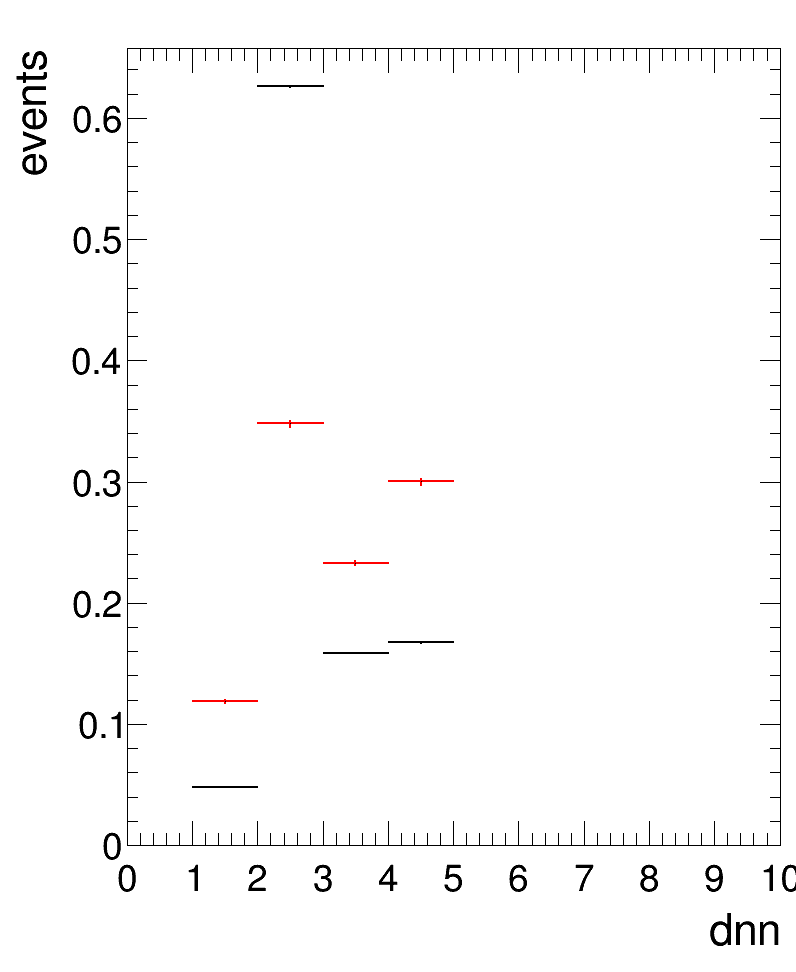

In [40]:
c = rt.TCanvas("c","c",800,1000)
h = {}
i = 0
for k, T, in tree.items():
    # h[k] = create_TH1D(np.array(clusterDNN[k][:,0]), name = "", title = "", axis_title= ["dnn","events"], binning = [100,0.7,1])
    # h[k] = create_TH1D(np.array(cscRechitClusterSize1[k]), name = "", title = "", axis_title= ["dnn","events"], binning = [100,50,1000])
    h[k] = create_TH1D(np.array(T['cscRechitClusterMaxStation'].array()[:,0]), name = "", title = "", axis_title= ["dnn","events"], binning = [10,0,10])
    h[k].Scale(1./h[k].Integral())
    h[k].SetLineColor(std_color_list[i])
    i+=1
    h[k].Draw("same")
c.Draw()

## CSC-DT

In [8]:
%%time
CSC = 'cscRechitCluster'
DT = 'dtRechitCluster'

MET_CUT = 200
MET_THRESHOLD = 50

HIT_THRESHOLD = { #cscnhit, dtnhit, dphi
    'lowMET': (160, 130, 2.5),
    'highMET':(80, 130, 2.7),
}



name = [
"nCscCluster = 1, nDtCluster = 1",
"HLTDecision",
"Offline HLT cut",
"Apply L1 efficiency weight",
f"MET < {MET_CUT}",
"noise filter",
"jet veto",
"muon veto",
"ME1 veto",
"time spread",
"time",
"DNN",
"deltaPhi",
"CSC Hit",
    ]
for k,T in tree.items():
    if  not 'data' in k:continue
    for cat in ['lowMET', 'highMET']:
        print("************************************")
        print(k, cat)
        print("************************************")

        if 'data' in k: 
            weight = T['weight'].array()
            total = NEvents[k]
        else: 
            weight = T['pileupWeight'].array()*T['weight'].array()*LUMI_SCALE
            total = 52.2*50000*LUMI_SCALE

        presel =  (T["nCscRechitClusters"].array() == 1) & (T["nDtRechitClusters"].array() == 1)
        print('\t'.join(str(x) for x in [name[0],  np.sum(weight[presel]), np.sum(weight[presel])/total, np.sum(weight[presel]/total)]))
        temp = np.sum(weight[presel])

        presel =  presel & T['HLT_CSCDT'].array()
        print('\t'.join(str(x) for x in [name[1],  np.sum(weight[presel]), np.sum(weight[presel])/temp, np.sum(weight[presel]/total)]))
        temp = np.sum(weight[presel])


        #apply L1 efficiency
        if 'sig' in k:
            HMTEff = T['cscRechitClusterHMTEfficiency'].array()[presel][:,0]
            weight = weight[presel] * HMTEff
        else: weight = weight[presel]
        print('\t'.join(str(x) for x in [name[3],  np.sum(weight), np.sum(weight)/temp, np.sum(weight/total)]))
        temp = np.sum(weight)

        dPhi = deltaPhi(np.array(T['cscRechitClusterPhi'].array()[presel][:,0]), np.array(T['dtRechitClusterPhi'].array()[presel][:,0]))

        selections = {
            "met < 200": (T['met'].array() < 200)[presel],
            f"met < {MET_THRESHOLD}": (T['met'].array() < MET_THRESHOLD)[presel],
            f"met > {MET_THRESHOLD}": (T['met'].array() > MET_THRESHOLD)[presel],
            "noise filter": (T['Flag_all'].array())[presel],
            ### CSC cluster-level selections ###

            "CSC jet veto": (T[f'{CSC}JetVetoPt'].array()<30)[presel][:,0],
            "CSC muon veto": np.logical_not((T[f'{CSC}MuonVetoPt'].array() > 30) & T[f'{CSC}MuonVetoGlobal'].array())[presel][:,0],
            "CSC ME1 veto": ((T[f'{CSC}NRechitChamberPlus11'].array()+ T[f'{CSC}NRechitChamberPlus12'].array()+\
            T[f'{CSC}NRechitChamberMinus11'].array()+ T[f'{CSC}NRechitChamberMinus12'].array())==0)[presel][:,0],
            "CSC time spread": (T[f'{CSC}TimeSpreadWeightedAll'].array()<20)[presel][:,0],
            "CSC time cut": (T[f'{CSC}TimeWeighted'].array()< 12.5)[presel][:,0] & (T[f'{CSC}TimeWeighted'].array()>-5)[presel][:,0],
            "CSC DNN": (T[f'{CSC}DNN_bkgMC_plusBeamHalo'].array()>0.96)[presel][:,0],
            f"CSC Nhits > {HIT_THRESHOLD[cat][0]}": (T[f'{CSC}Size'].array()>HIT_THRESHOLD[cat][0])[presel][:,0],

            ### DT cluster-level selections ###
            "DT jet veto":(T[f'{DT}JetVetoPt'].array()<30)[presel][:,0],
            "DT muon veto":np.logical_not((T[f'{DT}MuonVetoPt'].array() > 30) & T[f'{DT}MuonVetoLooseId'].array())[presel][:,0],
            "DT MB1 veto":(T[f'{DT}NHitStation1'].array()==0)[presel][:,0],
            "DT RPC hit":(T[f'{DT}_match_RPChits_dPhi0p5'].array() >= 1)[presel][:,0],
            "DT BX":(T[f'{DT}_match_RPCBx_dPhi0p5'].array() == 0)[presel][:,0],
            f"deltaPhi >= {HIT_THRESHOLD[cat][2]}": np.abs(dPhi) >= HIT_THRESHOLD[cat][2],
            f"DT Nhits >= {HIT_THRESHOLD[cat][1]}":(T[f'{DT}Size'].array() >= HIT_THRESHOLD[cat][1])[presel][:,0],
        }

        for i, sel_k in enumerate(selections.keys()):
            if i == len(selections.keys())-1 and 'data' in k:continue
            if 'high' in cat and f"met < {MET_THRESHOLD}" in sel_k:continue
            if 'low' in cat and f"met > {MET_THRESHOLD}" in sel_k:continue
            if i == 0:sel = selections[sel_k]
            else: sel = sel & selections[sel_k]
            print('\t'.join(str(x) for x in [sel_k,  np.sum(weight[sel]), np.sum(weight[sel])/temp, np.sum(weight[sel]/total)]))
            temp = np.sum(weight[sel])



CPU times: user 15 µs, sys: 0 ns, total: 15 µs
Wall time: 18.6 µs


In [9]:
T = tree['dataall']
np.sum(T['Flag_all'].array()[presel])/len(T['Flag_all'].array()[presel])

KeyError: 'dataall'

In [ ]:
print("test")